In [53]:
import numpy as np
import matplotlib.pyplot as plt

### Тестові функції

In [54]:
def get_function(name, n_dim=2, use_constraints=False):
    """Вибір функції, розмірності та логіка обмежень (Розділ 4)"""
    
    if name == "rastrigin":
        # 4.1. Функція Растригіна (безумовна)
        def f(x):
            return 10 * len(x) + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))
        return f, [(-5.12, 5.12)] * n_dim, 0

    elif name == "rosenbrock":
        # 4.2. Функція Розенброка (з обмеженнями)
        def f(x):
            val = (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2
            if use_constraints:
                g = x[0]**2 + x[1]**2 - 2 # x^2 + y^2 <= 2
                if g > 0: val += 1e8 * (g**2)
            return val
        return f, [(-2, 2)] * 2, 0

    elif name == "mishra_bird":
        # 4.3. Функція Мішри-Берда (з обмеженнями)
        def f(x):
            val = np.exp((1 - np.cos(x[0]))**2) * np.sin(x[1]) + \
                  np.exp((1 - np.sin(x[1]))**2) * np.cos(x[0]) + (x[0] - x[1])**2
            if use_constraints:
                g = (x[0] + 5)**2 + (x[1] + 5)**2 - 25 # коло
                if g > 0: val += 1e8 * (g**2)
            return val
        return f, [(-10, 0), (-6.5, 0)], -106.76

### Реалізація алгоритмів

#### PSO

In [55]:
def run_pso(func, bounds, n_iter=150, n_part=40):
    dim = len(bounds)
    # Визначаємо нижні та верхні межі пошуку
    lb, ub = np.array([b[0] for b in bounds]), np.array([b[1] for b in bounds])
    
    # Ініціалізація: випадкові позиції та нульові швидкості
    pos = np.random.uniform(lb, ub, (n_part, dim))
    vel = np.zeros((n_part, dim))
    
    # pbest — найкраща позиція кожної окремої частинки
    pbest_pos, pbest_fit = pos.copy(), np.array([func(p) for p in pos])
    
    # gbest — найкраща позиція серед усіх частинок (глобальний лідер)
    gbest_fit = np.min(pbest_fit)
    gbest_pos = pbest_pos[np.argmin(pbest_fit)].copy()
    
    h_best, h_pop = [], []
    for _ in range(n_iter):
        fits = []
        for i in range(n_part):
            # r1, r2 — випадкові вектори для додавання стохастичності
            r1, r2 = np.random.rand(dim), np.random.rand(dim)
            
            # ОНОВЛЕННЯ ШВИДКОСТІ (Формула 1 з методички):
            # 0.5*vel — інерція; 2.0*r1*(pbest-pos) — когнітивна частина; 2.0*r2*(gbest-pos) — соціальна частина
            vel[i] = 0.5*vel[i] + 2.0*r1*(pbest_pos[i]-pos[i]) + 2.0*r2*(gbest_pos-pos[i])
            
            # ОНОВЛЕННЯ ПОЗИЦІЇ: нова позиція = стара + швидкість
            pos[i] = np.clip(pos[i] + vel[i], lb, ub)
            
            f_val = func(pos[i])
            fits.append(f_val)
            
            # Якщо нова позиція краща за попередню власну — оновлюємо pbest
            if f_val < pbest_fit[i]:
                pbest_fit[i], pbest_pos[i] = f_val, pos[i].copy()
                # Якщо нова позиція краща за глобальну — оновлюємо gbest
                if f_val < gbest_fit: 
                    gbest_fit, gbest_pos = f_val, pos[i].copy()
                    
        h_best.append(gbest_fit); h_pop.append(fits)
    return h_best, h_pop

#### Bee

In [56]:
def run_bee(func, bounds, n_iter=150, n_bees=40):
    dim = len(bounds)
    lb, ub = np.array([b[0] for b in bounds]), np.array([b[1] for b in bounds])
    # Початкова популяція бджіл-розвідників
    pop = np.random.uniform(lb, ub, (n_bees, dim))
    h_best, h_pop = [], []
    
    for _ in range(n_iter):
        # Оцінка пристосованості та сортування за якістю ділянок
        fits = np.array([func(p) for p in pop])
        idx = np.argsort(fits)
        pop, fits = pop[idx], fits[idx]
        
        h_best.append(fits[0]); h_pop.append(fits.tolist())
        
        new_pop = []
        # ЛОКАЛЬНИЙ ПОШУК (на m=12 найкращих ділянках)
        for i in range(12): 
            best_l = pop[i]
            # Якщо ділянка елітна (перші 4), туди відправляємо більше бджіл (20), інакше 12
            num_local_bees = 20 if i < 4 else 12
            for _ in range(num_local_bees):
                # Пошук у вузькому околі ділянки (радіус 0.5)
                cand = np.clip(best_l + np.random.uniform(-0.5, 0.5, dim), lb, ub)
                if func(cand) < func(best_l): 
                    best_l = cand
            new_pop.append(best_l)
            
        # ГЛОБАЛЬНИЙ ПОШУК (Бджоли-розвідники)
        # Решта бджіл просто шукають випадкові нові ділянки по всьому полю
        while len(new_pop) < n_bees: 
            new_pop.append(np.random.uniform(lb, ub, dim))
        pop = np.array(new_pop)
        
    return h_best, h_pop

#### Firefly

In [57]:
def run_firefly(func, bounds, n_iter=150, n_flies=25):
    dim = len(bounds)
    lb, ub = np.array([b[0] for b in bounds]), np.array([b[1] for b in bounds])
    # Початкове розселення світлячків
    pop = np.random.uniform(lb, ub, (n_flies, dim))
    fits = np.array([func(p) for p in pop])
    h_best, h_pop = [], []
    
    for _ in range(n_iter):
        h_best.append(np.min(fits)); h_pop.append(fits.copy())
        
        for i in range(n_flies):
            for j in range(n_flies):
                # Якщо світлячок j яскравіший за i (значення функції менше)
                if fits[j] < fits[i]:
                    # Рахуємо відстань між ними
                    r = np.linalg.norm(pop[i]-pop[j])
                    # beta — коефіцієнт привабливості (затухає з відстанню r)
                    beta = 1.0 * np.exp(-0.1 * r**2)
                    
                    # РУХ (Формула з п. 3.2):
                    # крок до яскравішого + випадковий крок для дослідження
                    step = 0.2 * (np.random.rand(dim) - 0.5)
                    pop[i] = np.clip(pop[i] + beta*(pop[j]-pop[i]) + step, lb, ub)
                    
                    # Оновлюємо пристосованість після руху
                    fits[i] = func(pop[i])
                    
    return h_best, h_pop

#### Візуалізація

In [58]:
def plot_lab(h_best, h_pop, opt, title):
    fig, ax = plt.subplots(1, 3, figsize=(18, 4))
    h_pop = np.array(h_pop)
    # Пристосованість
    for i in range(h_pop.shape[1]): ax[0].plot(h_pop[:, i], color='blue', alpha=0.1)
    ax[0].set_title("Пристосованість популяції"); ax[0].set_yscale('log')
    # Відстань до оптимуму
    ax[1].plot([abs(b - opt) for b in h_best], color='red', lw=2)
    ax[1].set_title("Відстань до оптимуму"); ax[1].set_yscale('log')
    # Збіжність
    ax[2].plot(h_best, color='green', lw=2)
    ax[2].set_title("Збіжність (Best Fit)")
    plt.suptitle(title); plt.tight_layout(); plt.show()

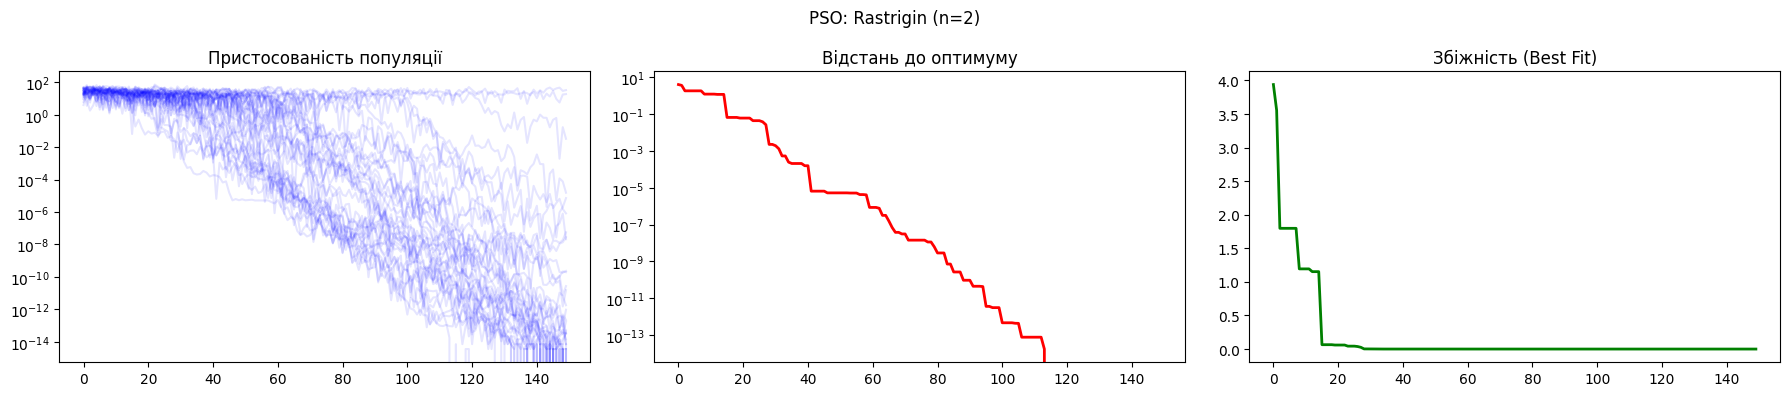

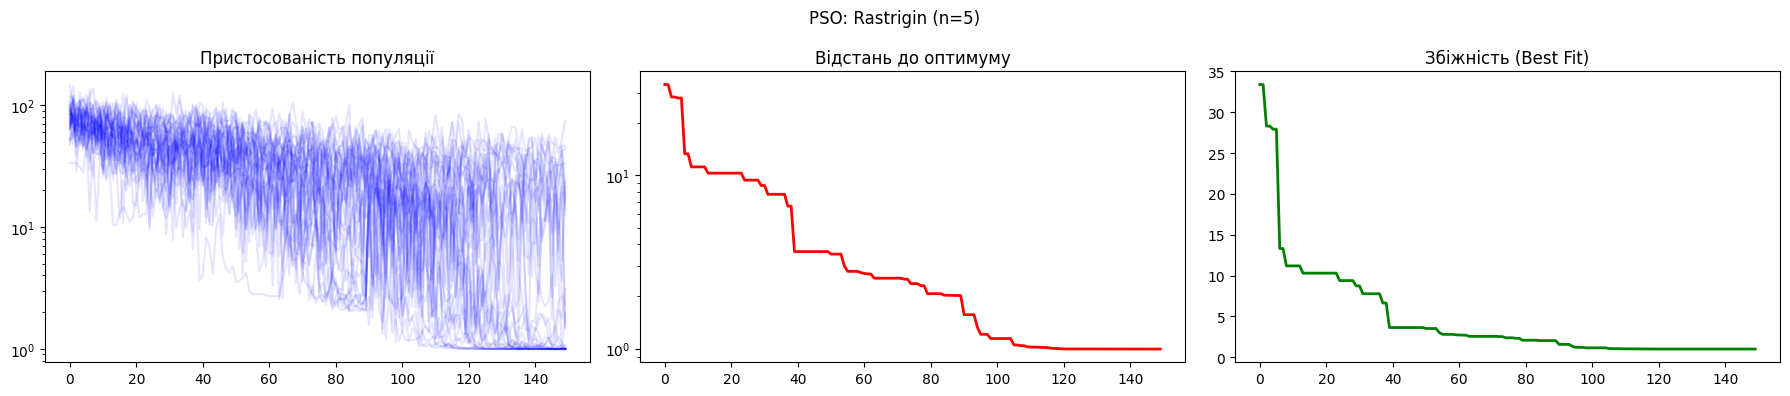

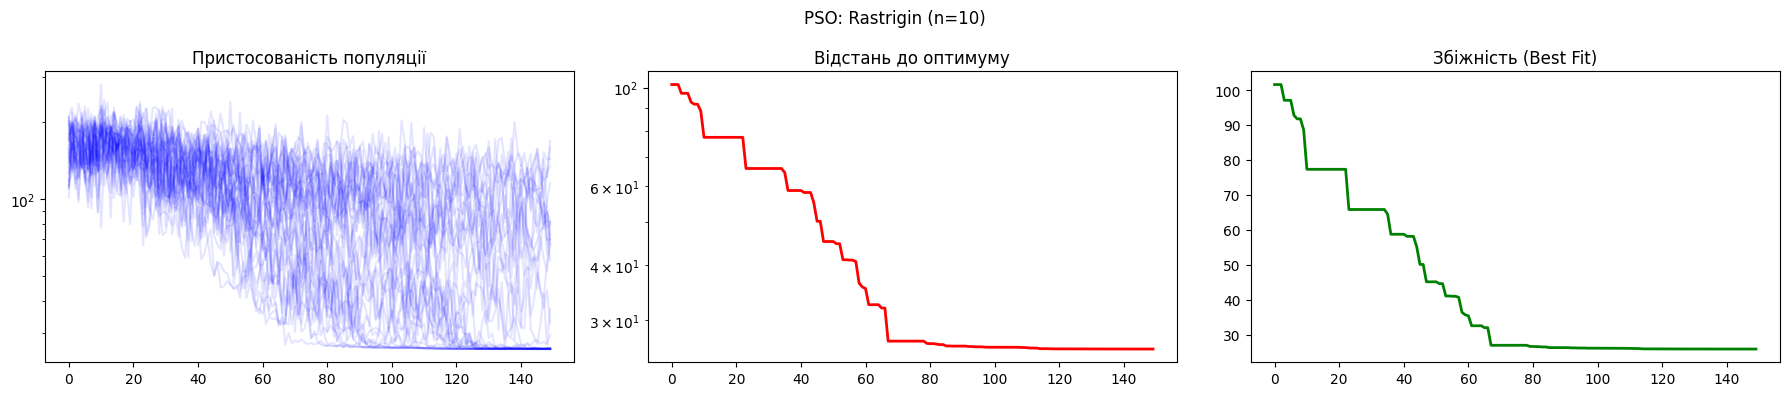

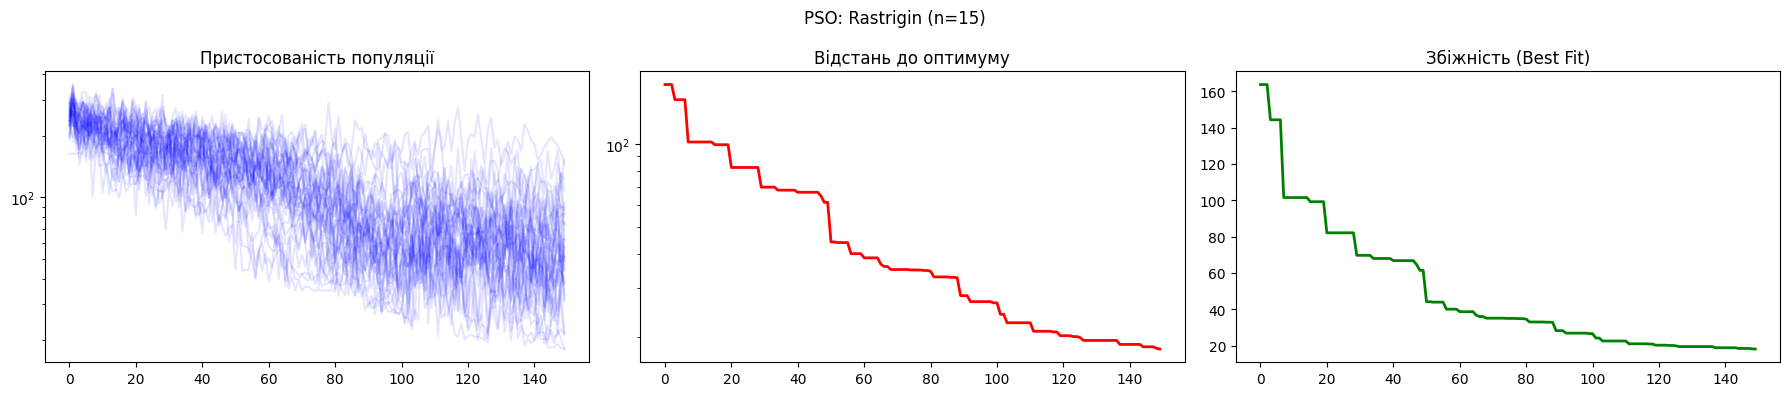

In [59]:
# --- ТЕСТУВАННЯ РАСТРИГІНА ДЛЯ n = 2, 5, 10, 15 ---
for n in [2, 5, 10, 15]:
    f, bnd, opt = get_function("rastrigin", n_dim=n)
    # Використовуємо PSO як основний приклад для різних n
    h_b, h_p = run_pso(f, bnd, n_iter=150)
    plot_lab(h_b, h_p, opt, f"PSO: Rastrigin (n={n})")

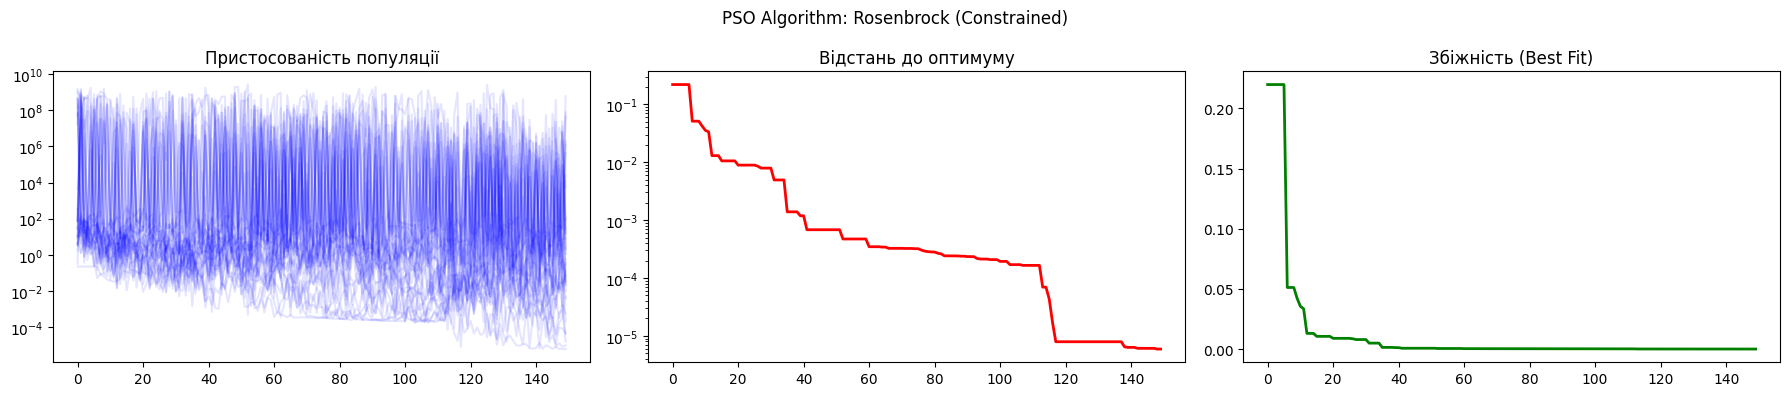

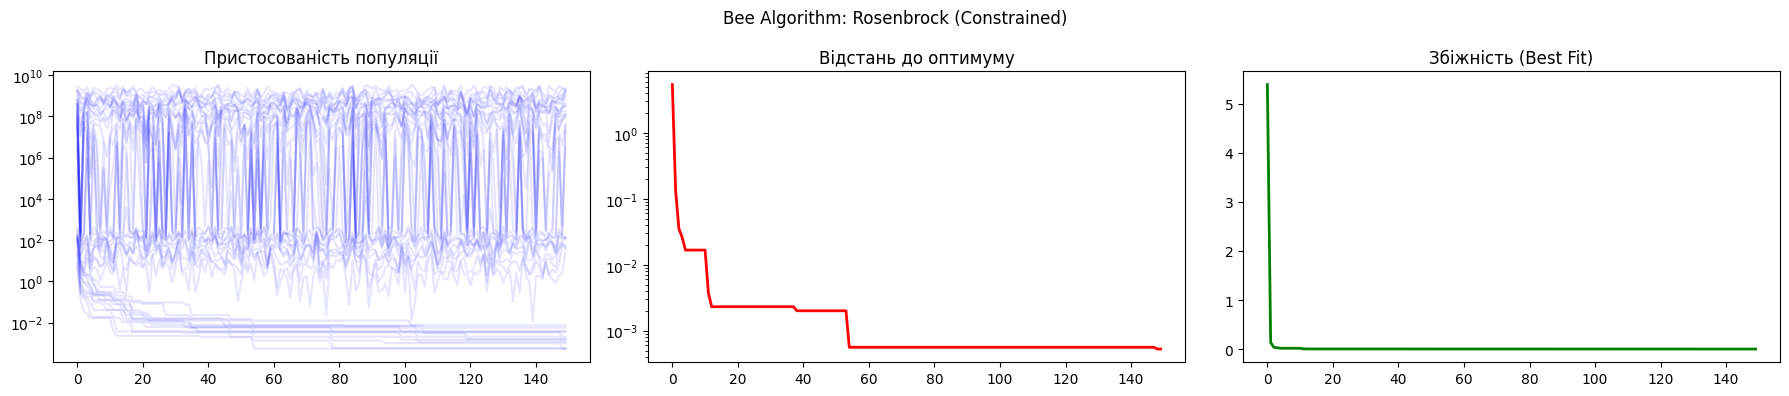

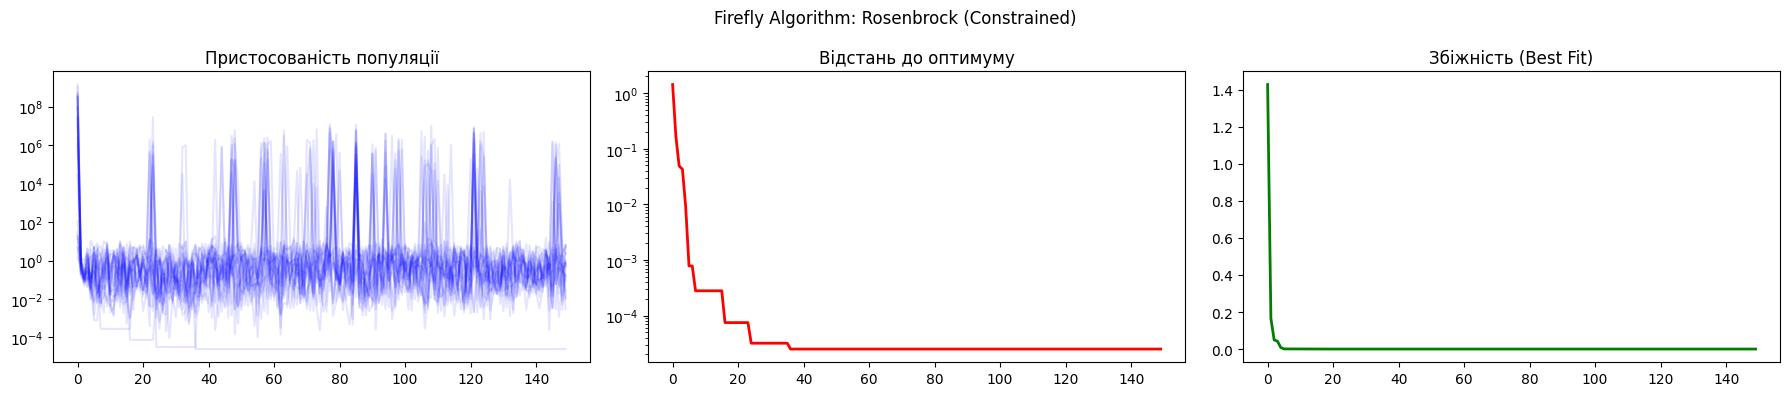

In [60]:
# --- ТЕСТУВАННЯ ФУНКЦІЙ З ОБМЕЖЕННЯМИ ---
f_ros, b_ros, opt_ros = get_function("rosenbrock", use_constraints=True)
h_b, h_p = run_pso(f_ros, b_ros)
plot_lab(h_b, h_p, opt_ros, "PSO Algorithm: Rosenbrock (Constrained)")

f_ros, b_ros, opt_ros = get_function("rosenbrock", use_constraints=True)
h_b, h_p = run_bee(f_ros, b_ros)
plot_lab(h_b, h_p, opt_ros, "Bee Algorithm: Rosenbrock (Constrained)")

f_ros, b_ros, opt_ros = get_function("rosenbrock", use_constraints=True)
h_b, h_p = run_firefly(f_ros, b_ros)
plot_lab(h_b, h_p, opt_ros, "Firefly Algorithm: Rosenbrock (Constrained)")

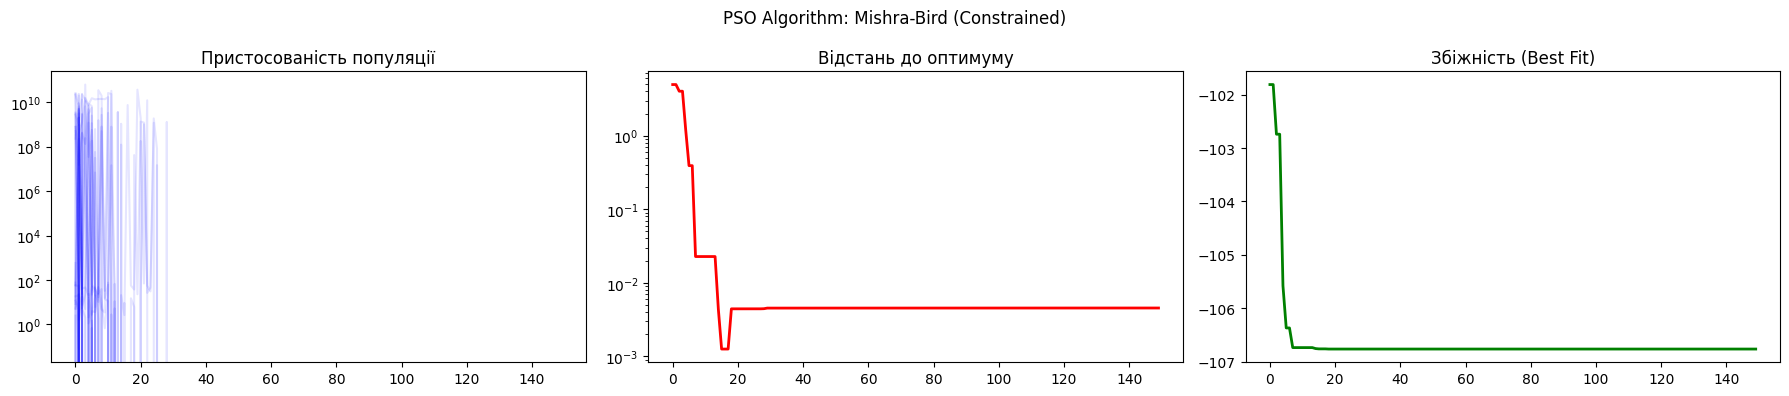

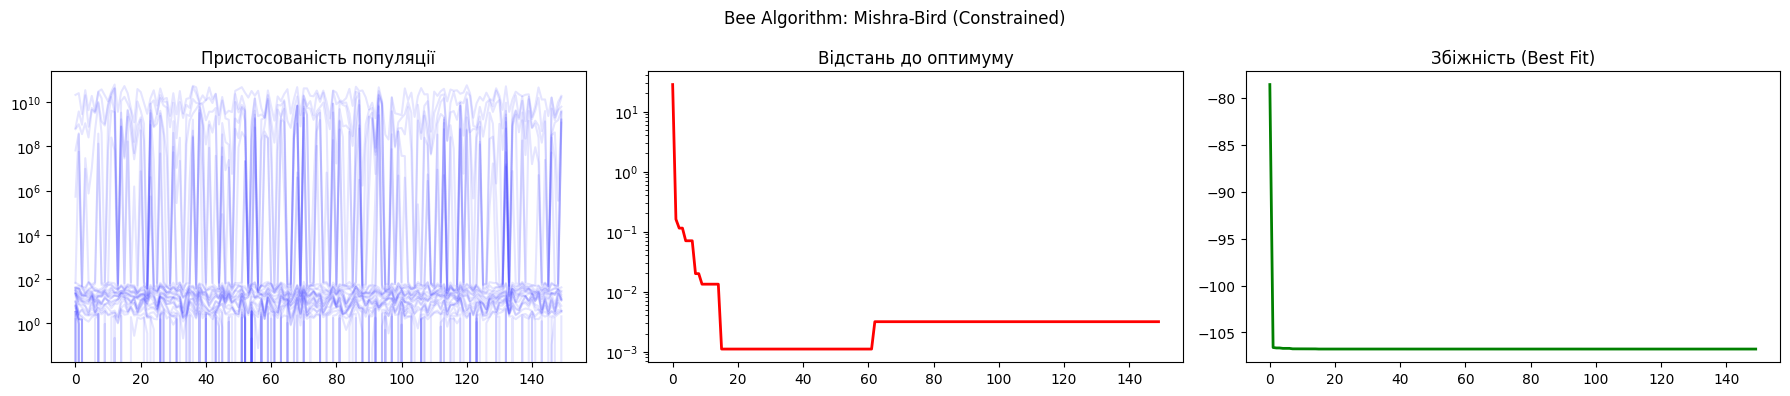

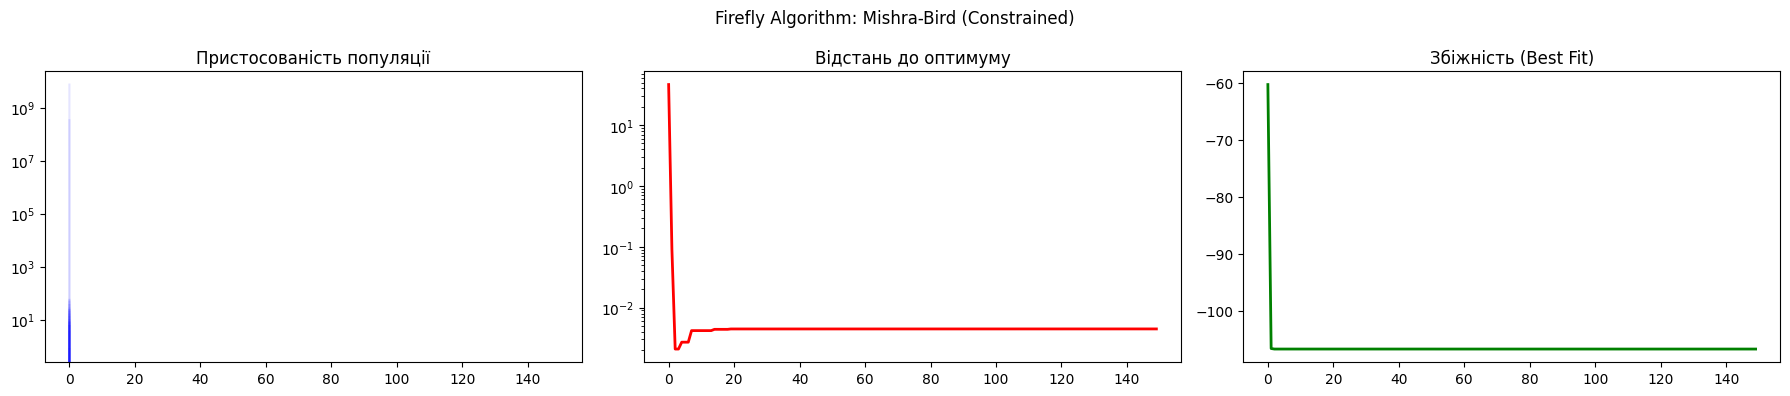

In [61]:
f_mb, b_mb, opt_mb = get_function("mishra_bird", use_constraints=True)
h_b, h_p = run_pso(f_mb, b_mb)
plot_lab(h_b, h_p, opt_mb, "PSO Algorithm: Mishra-Bird (Constrained)")

f_mb, b_mb, opt_mb = get_function("mishra_bird", use_constraints=True)
h_b, h_p = run_bee(f_mb, b_mb)
plot_lab(h_b, h_p, opt_mb, "Bee Algorithm: Mishra-Bird (Constrained)")

f_mb, b_mb, opt_mb = get_function("mishra_bird", use_constraints=True)
h_b, h_p = run_firefly(f_mb, b_mb)
plot_lab(h_b, h_p, opt_mb, "Firefly Algorithm: Mishra-Bird (Constrained)")

### Вирішення задачі мінімізації ваги редуктора

In [ ]:
def pressure_vessel_task(x):
    """
    x1: b (ширина обшивки)
    x2: m (модуль колеса)
    x3: z (число зубів колеса) - ЦІЛА ЗМІННА
    x4: l1 (довжина 1-го валу)
    x5: l2 (довжина 2-го валу)
    x6: d1 (діаметр 1-го валу)
    x7: d2 (діаметр 2-го валу)
    """
    # Змінна x3 є цілою, тому округлюємо її
    x1, x2, x4, x5, x6, x7 = x[0], x[1], x[3], x[4], x[5], x[6]
    x3 = np.round(x[2]) 
    
    # Цільова функція f(x) -> min
    f = 0.7854 * x1 * (x2**2) * (3.3333 * x3**2 + 14.9334 * x3 - 43.0934) \
        - 1.508 * x1 * (x6**2 + x7**2) \
        + 7.4777 * (x6**3 + x7**3) \
        + 0.7854 * (x4 * x6**2 + x5 * x7**2)
        
    # Масив для 11 обмежень g(x) <= 0
    g = np.zeros(11)
    
    g[0] = 27.0 / (x1 * x2**2 * x3) - 1.0
    g[1] = 397.5 / (x1 * x2**2 * x3**2) - 1.0
    g[2] = (1.93 * x4**3) / (x2 * x3 * x6**4) - 1.0
    g[3] = (1.93 * x5**3) / (x2 * x3 * x7**4) - 1.0
    g[4] = (1.0 / (110.0 * x6**3)) * np.sqrt((745.0 * x4 / (x2 * x3))**2 + 16.9e6) - 1.0
    g[5] = (1.0 / (85.0 * x7**3)) * np.sqrt((745.0 * x5 / (x2 * x3))**2 + 157.5e6) - 1.0
    g[6] = (x2 * x3) / 40.0 - 1.0
    g[7] = (5.0 * x2) / x1 - 1.0
    g[8] = x1 / (12.0 * x2) - 1.0
    g[9] = (1.5 * x6 + 1.9) / x4 - 1.0
    g[10] = (1.1 * x7 + 1.9) / x5 - 1.0
    
    # Метод штрафів за порушення обмежень
    penalty = 0
    for val in g:
        if val > 0:
            penalty += 1e9 * (val**2) # Великий штраф, щоб алгоритм тікав у допустиму область
            
    return f + penalty

In [ ]:
# Простір пошуку згідно з методичкою:
BOUNDS_5_1 = [
    (2.6, 3.6),  # x1
    (0.7, 0.8),  # x2
    (17, 28),    # x3
    (7.3, 8.3),  # x4
    (7.8, 8.3),  # x5
    (2.9, 3.9),  # x6
    (5.0, 5.5)   # x7
]

# Відомий оптимум ваги для цієї стандартної задачі становить ~2994.4
KNOWN_OPTIMUM = 2994.4

### Візуалізація

In [ ]:
def plot_task(h_best, h_pop, opt, title):
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    h_pop = np.array(h_pop)
    
    # 1. Графік пристосованості популяції 
    for i in range(h_pop.shape[1]):
        ax[0].plot(h_pop[:, i], color='blue', alpha=0.1)
    ax[0].set_title("Пристосованість популяції")
    ax[0].set_yscale('log')
    ax[0].set_xlabel("Ітерації")

    # 2. Графік відстані до оптимуму
    dist = [abs(b - opt) for b in h_best]
    ax[1].plot(dist, color='red', lw=2)
    ax[1].set_title("Відстань до оптимальної ваги (~2994.4)")
    ax[1].set_yscale('log')
    ax[1].set_xlabel("Ітерації")

    # 3. Динаміка збіжності
    ax[2].plot(h_best, color='green', lw=2)
    ax[2].set_title("Найкраща знайдена вага редуктора")
    ax[2].set_xlabel("Ітерації")
    ax[2].set_yscale('log')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

Вирішення задачі: Мінімізація ваги редуктора (7 змінних)...


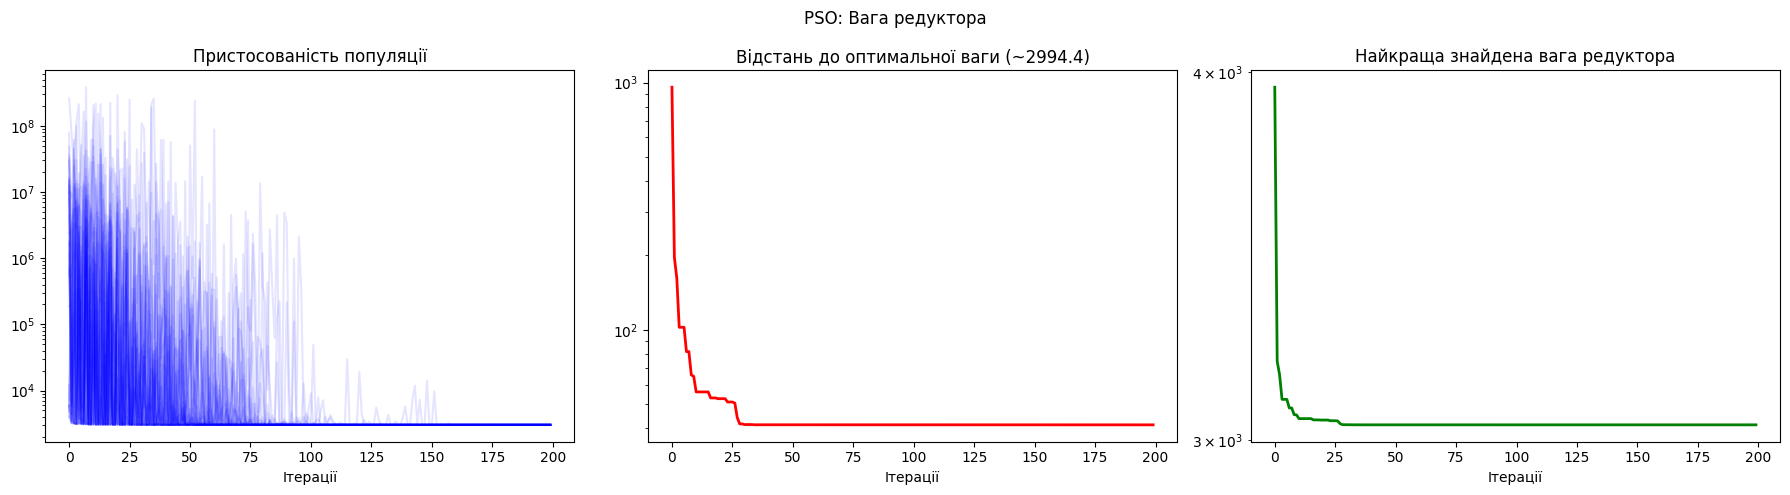

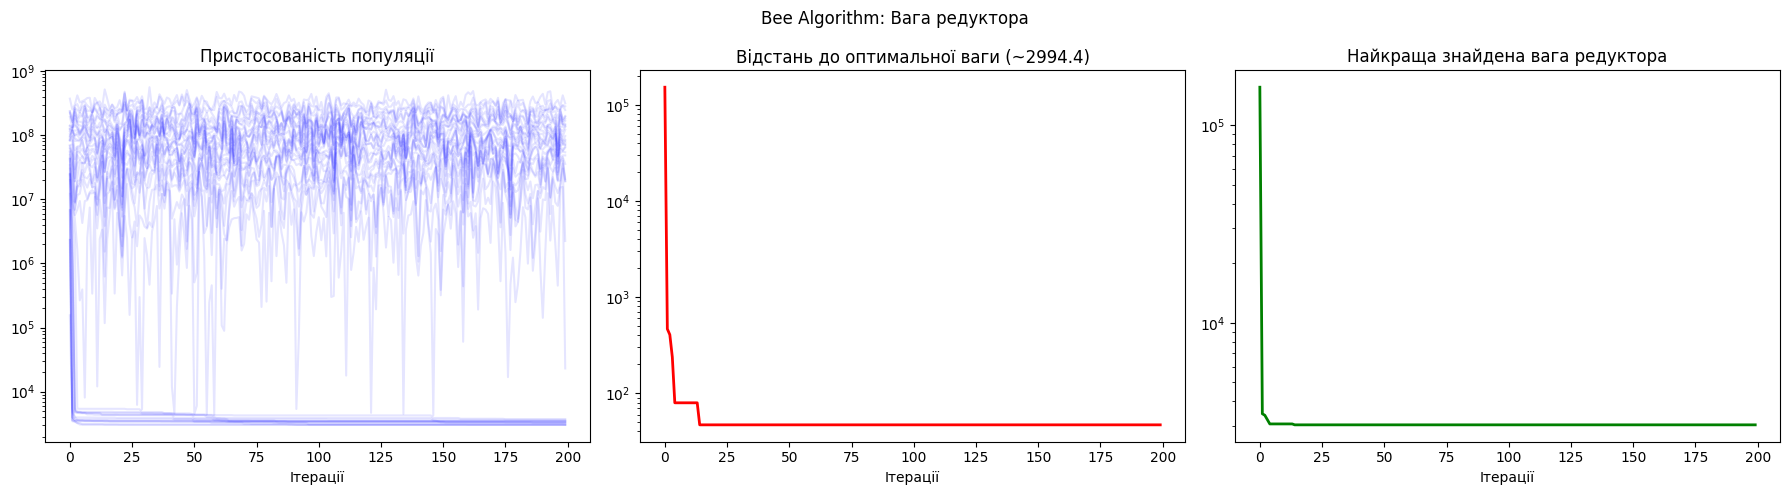

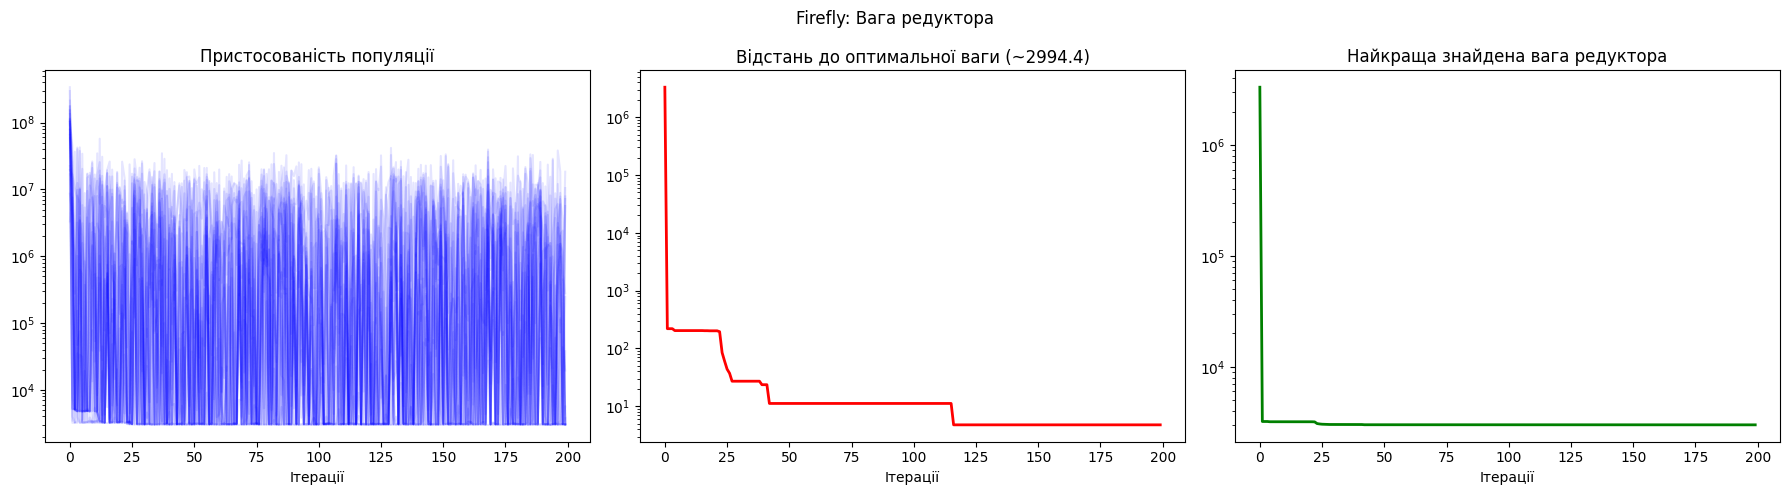

In [ ]:
print("Вирішення задачі: Мінімізація ваги редуктора (7 змінних)...")

h_b_pso, h_p_pso = run_pso(pressure_vessel_task, BOUNDS_5_1, n_iter=200)
plot_task(h_b_pso, h_p_pso, KNOWN_OPTIMUM, "PSO: Вага редуктора")

h_b_bee, h_p_bee = run_bee(pressure_vessel_task, BOUNDS_5_1, n_iter=200)
plot_task(h_b_bee, h_p_bee, KNOWN_OPTIMUM, "Bee Algorithm: Вага редуктора")

h_b_ff, h_p_ff = run_firefly(pressure_vessel_task, BOUNDS_5_1, n_iter=200)
plot_task(h_b_ff, h_p_ff, KNOWN_OPTIMUM, "Firefly: Вага редуктора")